In [1]:
import torch
import matplotlib.pyplot as plt
import mylib

from torch import nn

In [24]:
def f(x):
    return 2 * torch.sin(x) + x**0.8

"""
def plot_kernel_reg(y_hat):
    fig, axes = plt.subplots(1, 2, squeeze=False)
    mylib.plot(x_test, [y_truth, y_hat], 'x', 'y', legend=['Truth', 'Pred'], xlim=[0, 5], ylim=[-1, 5], axes=axes[0][0])
    axes[0][1].plot(x_train, y_train, 'o', alpha=0.5)
"""

def plot_kernel_reg(y_hat):
    mylib.plot(x_test, [y_truth, y_hat], 'x', 'y', legend=['Truth', 'Pred'], xlim=[0, 5], ylim=[-1, 5])
    plt.plot(x_train, y_train, 'o', alpha=0.5)


class NWKernelRegression(nn.Module):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.w = nn.Parameter(torch.rand((1,), requires_grad=True))

    def forward(self, queries, keys, values):
        # queries和attention_weights阶数: (查询个数, key-value数)
        queries = queries.repeat_interleave(keys.shape[1]).reshape((-1, keys.shape[1]))
        self.attention_weights = nn.functional.softmax(- ((queries - keys) * self.w)**2 / 2, dim=1)
        # values阶数为(查询个数, key-value数)
        # 做bmm后，阶数为(查询个数, (1 * key-value) * (key-value * 1))
        return torch.bmm(self.attention_weights.unsqueeze(1), values.unsqueeze(-1)).reshape(-1)




In [25]:
n_train = 50    # 训练样本数
x_train, _ = torch.sort(torch.rand(n_train) * 5)    # [0,5)排序后的训练样本

y_train = f(x_train) + torch.normal(0, 0.5, (n_train,))
x_test = torch.arange(0, 5, 0.1)    # 测试样本
y_truth = f(x_test)
n_test = len(x_test)    # 测试样本数


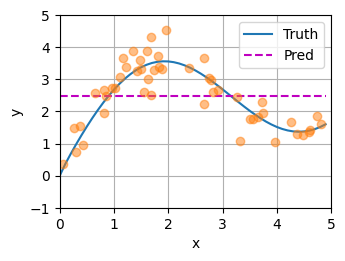

In [33]:
y_hat = torch.repeat_interleave(y_train.mean(), n_test)
plot_kernel_reg(y_hat)

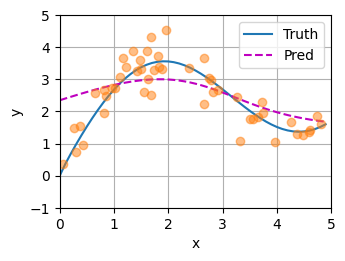

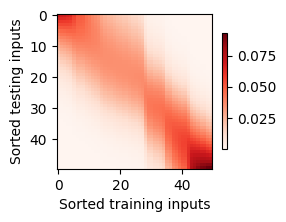

In [27]:
# 生成[[x_1, x_1, ..., x_1],
#      [x_2, x_2, ..., x_2],
#      ...,
#      [x_n, x_n, ..., x_n]]
# 每一行包含相同的查询（测试输入）
# 形状为(n_test, n_train)
X_repeat = x_test.repeat_interleave(n_train).reshape((-1, n_train))

attention_weights = nn.functional.softmax(-(X_repeat - x_train)**2 / 2, dim=1)
y_hat = attention_weights @ y_train
plot_kernel_reg(y_hat)
mylib.show_heatmaps(attention_weights.unsqueeze(0).unsqueeze(0),
                    xlabel = "Sorted training inputs",
                    ylabel="Sorted testing inputs")



In [28]:
# X_tile的形状:(n_train，n_train)，每一行都包含着相同的训练输入
X_tile = x_train.repeat((n_train, 1))
# Y_tile的形状:(n_train，n_train)，每一行都包含着相同的训练输出
Y_tile = y_train.repeat((n_train, 1))
# keys的形状:('n_train'，'n_train'-1)
keys = X_tile[(1 - torch.eye(n_train)).type(torch.bool)].reshape((n_train, -1))
# values的形状:('n_train'，'n_train'-1)
values = Y_tile[(1 - torch.eye(n_train)).type(torch.bool)].reshape((n_train, -1))

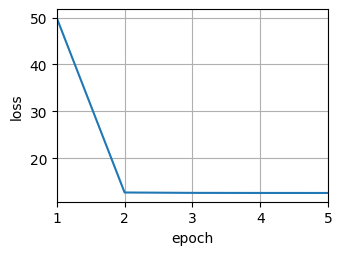

In [ ]:
net = NWKernelRegression()
loss = nn.MSELoss(reduction='none')
trainer = torch.optim.SGD(net.parameters(), lr=0.5)
animator = mylib.Animator(xlabel='epoch', ylabel='loss', xlim=[1, 5])

for epoch in range(5):
    trainer.zero_grad()
    l = loss(net(x_train, keys, values), y_train)
    l.sum().backward()
    trainer.step()
    print(f'epoch {epoch + 1}, loss {float(l.sum()):.6f}')
    animator.add(epoch + 1, float(l.sum()))

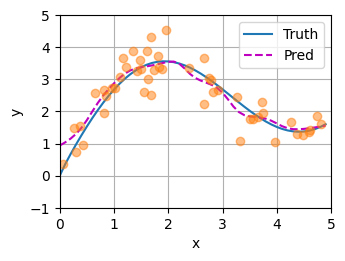

In [35]:
keys = x_train.repeat((n_test, 1))
values = y_train.repeat((n_test, 1))
y_hat = net(x_test, keys, values).unsqueeze(1).detach()
plot_kernel_reg(y_hat)


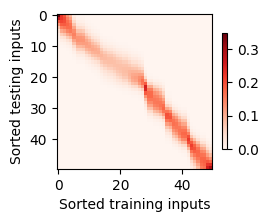

In [36]:
mylib.show_heatmaps(net.attention_weights.unsqueeze(0).unsqueeze(0),
                    xlabel='Sorted training inputs',
                    ylabel='Sorted testing inputs')

In [ ]:
net.attention_weights
"""
思考：学习到w参数后，可以看出注意力权重明显在对角线分布更集中，说明现在模型已经学到了在query的附近(x_test)的周围找近处的key(x_train)取值value，而学习之前明显查找的范围很广。

其中attention_weights的y轴表示每个query（每个测试点）, x轴表示对应的query中，响应最强的x_train点
"""


tensor([[0.3471, 0.2211, 0.1904,  ..., 0.0000, 0.0000, 0.0000],
        [0.2623, 0.2209, 0.2008,  ..., 0.0000, 0.0000, 0.0000],
        [0.1872, 0.2085, 0.2001,  ..., 0.0000, 0.0000, 0.0000],
        ...,
        [0.0000, 0.0000, 0.0000,  ..., 0.1805, 0.1907, 0.1746],
        [0.0000, 0.0000, 0.0000,  ..., 0.1760, 0.2241, 0.2305],
        [0.0000, 0.0000, 0.0000,  ..., 0.1637, 0.2514, 0.2907]],
       grad_fn=<SoftmaxBackward0>)